In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

In [53]:
# Imports

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Loading Data

In [54]:
# Loading the data
# Definitely using
sprint_results = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv')
results = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/results.csv')
races = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv')



# Possibly Using
constructor = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv')
constructor_results = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv')
constructor_standings = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv')
drivers = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv')
circuits = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/circuits.csv')







# Building Dataframe

In [57]:

# First combine all of the grand prix races and sprints, but keep an identifier so it is still possible to seperate them
sprints_df = sprint_results[["resultId","raceId", "driverId", "constructorId","grid", "positionOrder",'position']].copy()
sprints_df = sprints_df[sprints_df['grid']!=0].copy()
sprints_df['is_sprint'] = 1
results_df = results[['resultId','raceId','driverId','constructorId','grid','positionOrder','position']].copy()
results_df['is_sprint'] = 0
combined_df = pd.concat([results_df,sprints_df],axis=0)



#####################################################################################################
####### Possible testing: Remove outliers (DNF, etc) before doing feature engineering
#combined_df['position'] = pd.to_numeric(combined_df['position'], errors='coerce')
#combined_df = combined_df.dropna(subset=['position'])
#####################################################################################################



combined_df = combined_df.reset_index(drop=True)
# Next handle car and driver information
# Driver  
#driverID is unique, but adding name might make some results easier to understand
drivers_df = drivers[["driverId","forename","surname"]].copy()
combined_df = pd.merge(combined_df,drivers_df, on='driverId')
# Car
constructor_df = constructor[["constructorId","name"]].copy()
constructor_df = constructor_df.rename(columns={'name': 'constructorName'})
combined_df = pd.merge(combined_df,constructor_df,on='constructorId')
# Reorder 
combined_df.head()

,resultId,raceId,driverId,constructorId,grid,positionOrder,position,is_sprint,forename,surname,constructorName
0,1,18,1,1,1,1,1,0,Lewis,Hamilton,McLaren
1,2,18,2,2,5,2,2,0,Nick,Heidfeld,BMW Sauber
2,3,18,3,3,7,3,3,0,Nico,Rosberg,Williams
3,4,18,4,4,11,4,4,0,Fernando,Alonso,Renault
4,5,18,5,1,3,5,5,0,Heikki,Kovalainen,McLaren


In [58]:
# handling  / race /  information


# First combine race / circuit information


races_df = races[["raceId", "name", "year", 'date', "circuitId"]].copy()

races_df =  races_df.rename(columns={'name': 'race_name'})

circuits = circuits.rename(columns={'name': 'circuit_name'})

races_df = pd.merge(races_df,circuits[['circuitId','circuit_name']], on='circuitId')



# Combine with results

combined_df = pd.merge(combined_df,races_df,on='raceId')

# Reorder

combined_df = combined_df[['resultId', 'driverId','forename','surname','constructorId','constructorName','grid','positionOrder','raceId','race_name','circuitId','circuit_name','year','date','is_sprint']]
combined_df.head()




df = combined_df.copy()

# Data analysis / Feature Engineering

Determine the affect of a constructor by comparing the two drivers for the same constructor at each race

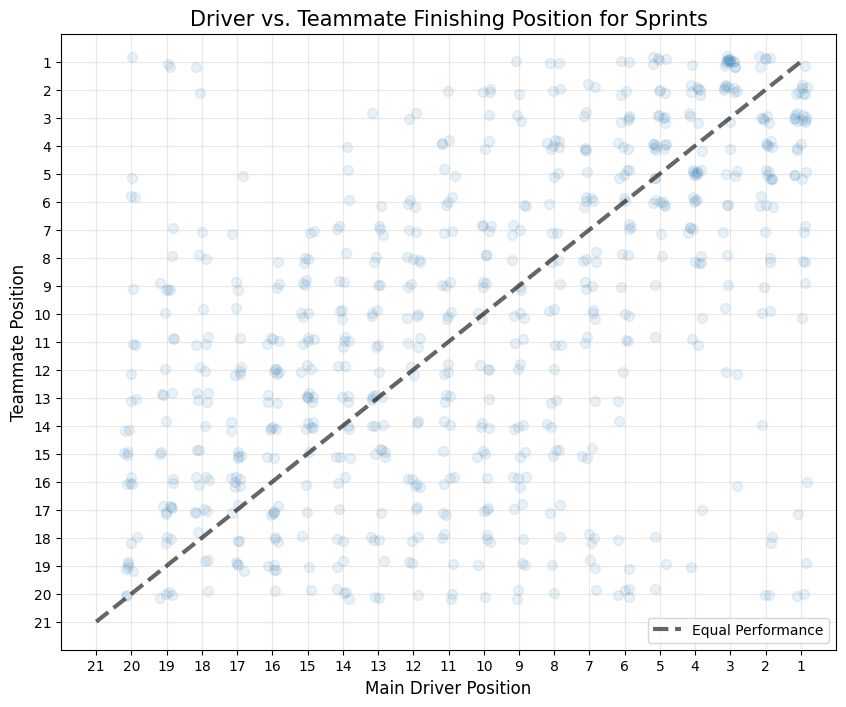

Constructor Correlation Coefficient: 0.52


In [59]:
analysis_df = df.copy()


# Compare teammates performance on the same race. A correlation would show that constructor has an effect
teammate_df = pd.merge(analysis_df,analysis_df,on = ['raceId', 'constructorId'], suffixes = ('','_teammate')).copy()
teammate_df = teammate_df[teammate_df['driverId'] != teammate_df['driverId_teammate']]
teammate_df = teammate_df[teammate_df['year'] >= 2014].copy()
teammate_df.head()
teammate_df = teammate_df[teammate_df['is_sprint'] == 1].copy()

plt.figure(figsize=(10, 8))


# Create the scatter plot
sns.regplot(
    data=teammate_df, 
    x='positionOrder', 
    y='positionOrder_teammate', 
    x_jitter=0.2,
    y_jitter=0.2,
    scatter_kws={'alpha':0.1,'s':50}, 

    fit_reg=False,
    #s=40,
    #color='skyblue',
    #edgecolor=None,
)
x = np.linspace(21, 1, 100)
y = x
plt.plot(x,y, color='black',linewidth=3,zorder=5, linestyle='--', alpha=0.6, label='Equal Performance')


plt.title('Driver vs. Teammate Finishing Position for Sprints', fontsize=15)
plt.xlabel('Main Driver Position', fontsize=12)
plt.ylabel('Teammate Position', fontsize=12)
plt.xticks(range(1, 22))
plt.yticks(range(1, 22))
plt.xlim(0,22)
plt.ylim(0,22)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.show()

correlation = teammate_df['positionOrder'].corr(teammate_df['positionOrder_teammate'])

print(f"Constructor Correlation Coefficient: {correlation:.2f}")


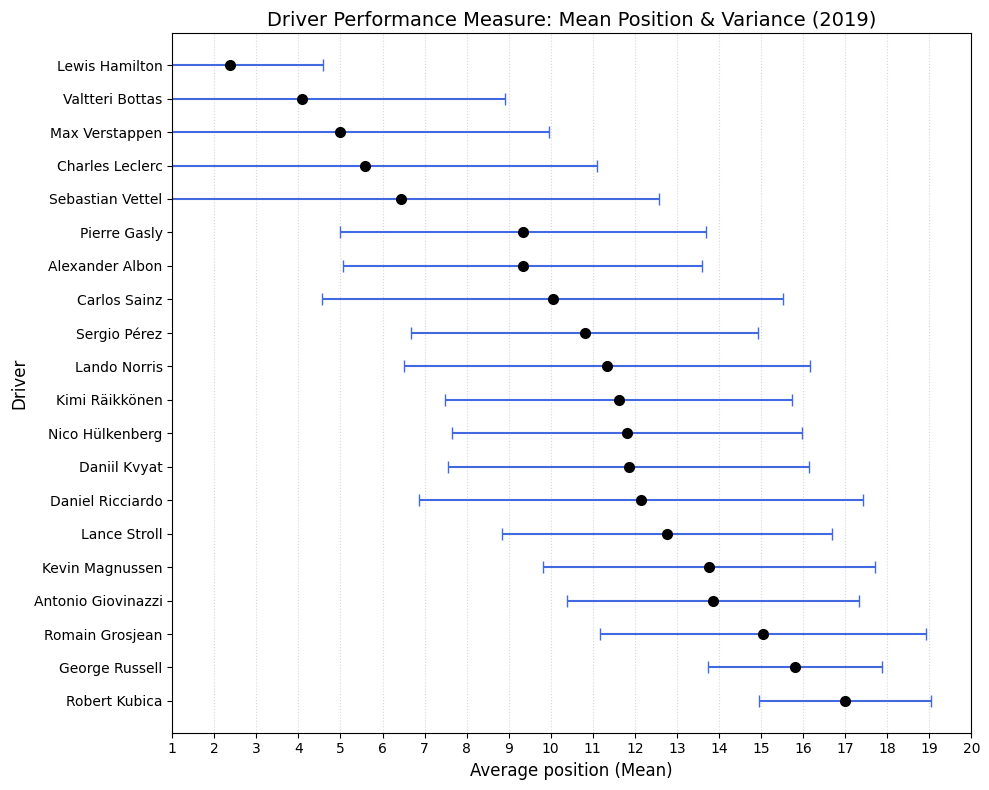

,driverId,forename,surname,mean,std,count
0,1,Lewis,Hamilton,2.380952,2.201731,21
8,822,Valtteri,Bottas,4.095238,4.805255,21
11,830,Max,Verstappen,5.000000,4.959839,21
16,844,Charles,Leclerc,5.571429,5.518799,21
3,20,Sebastian,Vettel,6.428571,6.152816,21
15,842,Pierre,Gasly,9.333333,4.351245,21
19,848,Alexander,Albon,9.333333,4.270051,21
12,832,Carlos,Sainz,10.047619,5.481571,21
6,815,Sergio,Pérez,10.809524,4.130606,21
17,846,Lando,Norris,11.333333,4.830459,21


In [60]:


df_modern = analysis_df[analysis_df['year'] == 2019].copy()


# 2. Grouping by driverid
# Using the new 'driverid' column for the Y-axis
driver_stats = df_modern.groupby(['driverId','forename','surname'])['positionOrder'].agg(['mean', 'std', 'count']).reset_index()

# Filter for consistency (e.g., drivers with more than 5 races)
driver_stats = driver_stats[driver_stats['count'] > 5].sort_values('mean')
# 3. Plotting


plt.figure(figsize=(10, 8))

plt.errorbar(
    x=driver_stats['mean'], 
    y=driver_stats['forename'] + " " + driver_stats['surname'],
    xerr=driver_stats['std'], 
    fmt='o', 
    color='black', 
    ecolor='royalblue', 
    capsize=4,
    markersize=7
)

# 4. Aesthetics (F1 standard: P1 at the top/left)
plt.gca().invert_yaxis() 
plt.xlim(1, 20)
plt.xticks(range(1, 21))

plt.title('Driver Performance Measure: Mean Position & Variance (2019)', fontsize=14)
plt.xlabel('Average position (Mean)', fontsize=12)
plt.ylabel('Driver', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('driver_performance_rank.png') # Saving for your paper
plt.show()

driver_stats.head(20)


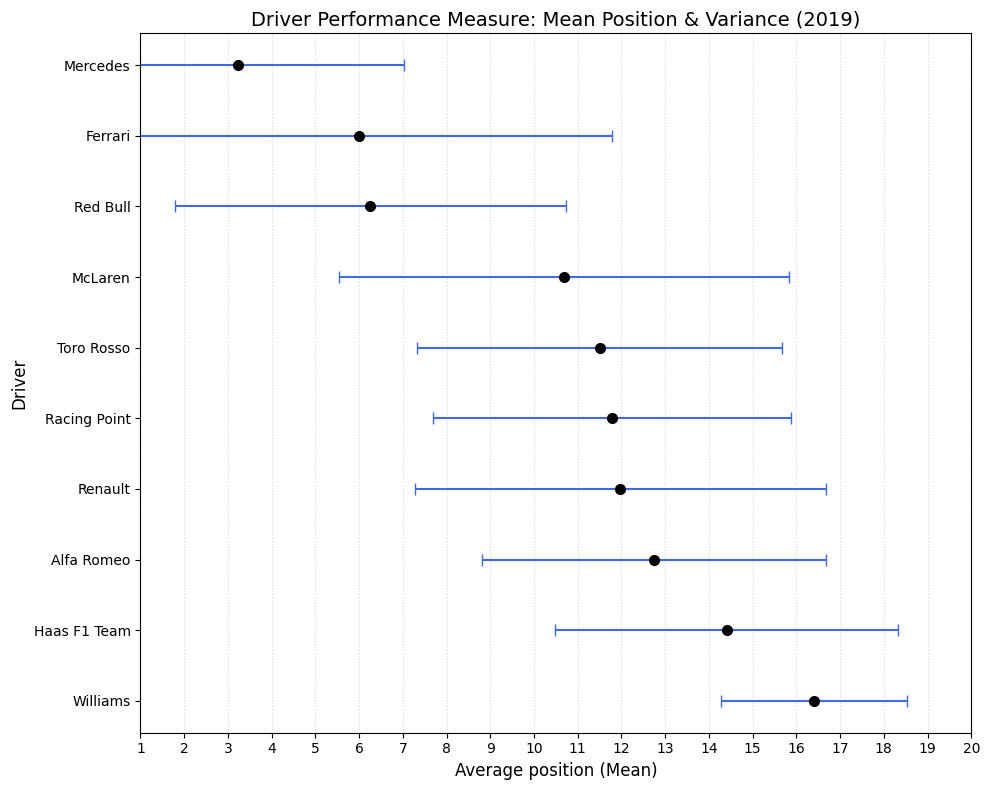

,constructorId,constructorName,mean,std,count
7,131,Mercedes,3.238095,3.792223,42
4,6,Ferrari,6.000000,5.788972,42
5,9,Red Bull,6.261905,4.477911,42
0,1,McLaren,10.690476,5.144204,42
3,5,Toro Rosso,11.500000,4.180384,42
9,211,Racing Point,11.785714,4.099588,42
2,4,Renault,11.976190,4.692953,42
6,51,Alfa Romeo,12.738095,3.932724,42
8,210,Haas F1 Team,14.404762,3.914074,42
1,3,Williams,16.404762,2.119129,42


In [61]:
# Repeat for constructor

df_modern = analysis_df[analysis_df['year'] == 2019].copy()


# 2. Grouping by driverid
driver_stats = df_modern.groupby(['constructorId','constructorName'])['positionOrder'].agg(['mean', 'std', 'count']).reset_index()

# Filter for consistency (e.g., drivers with more than 5 races)
driver_stats = driver_stats[driver_stats['count'] > 5].sort_values('mean')
# 3. Plotting


plt.figure(figsize=(10, 8))

plt.errorbar(
    x=driver_stats['mean'], 
    y=driver_stats['constructorName'],
    xerr=driver_stats['std'], 
    fmt='o', 
    color='black', 
    ecolor='royalblue', 
    capsize=4,
    markersize=7
)

# 4. Aesthetics (F1 standard: P1 at the top/left)
plt.gca().invert_yaxis() 
plt.xlim(1, 20)
plt.xticks(range(1, 21))

plt.title('Constructor Performance Measure: Mean Position & Variance (2019)', fontsize=14)
plt.xlabel('Average position (Mean)', fontsize=12)
plt.ylabel('Driver', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('driver_performance_rank.png') # Saving for your paper
plt.show()

driver_stats.head(20)


Constructor Correlation Coefficient: 0.78


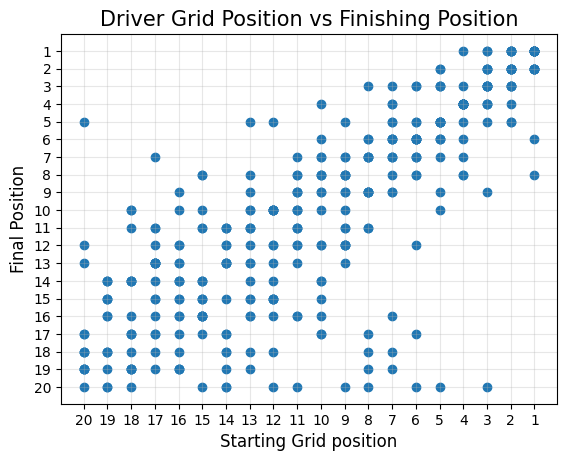

In [63]:
grid_position_df  = analysis_df[analysis_df['is_sprint']==1].copy()

x = grid_position_df['grid']
y= grid_position_df['positionOrder']

correlation = grid_position_df['positionOrder'].corr(grid_position_df['grid'])

print(f"Grid Position Correlation Coefficient: {correlation:.2f}")

plt.scatter(x,y)


plt.title('Driver Grid Position vs Finishing Position', fontsize=15)
plt.xlabel('Starting Grid position', fontsize=12)
plt.ylabel('Final Position', fontsize=12)
plt.xticks(range(1, 21))
plt.yticks(range(1, 21))
# plt.xlim(0,22)
# plt.ylim(0,22)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
# plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Historical Performance
Get the historical performance of a driver. Finds the averages of the drivers finishing position for all races before the current race.

In [71]:
# Historical Performance
# Calculate the historical performance of a specific driver
# The historical performance of each race will only be calculated with performance of races before

final_df = df.copy()
temp_df = combined_df.copy()


# For testing, I want to calculate these seperately for each race, and combined

gp_results_new = final_df[combined_df['is_sprint'] == 0]
sprint_results_new = final_df[combined_df['is_sprint'] == 1]



def historical_performance_stats(df):
    df = df.sort_values(['driverId', 'date'])
    df['hist_avg_pos'] = df.groupby('driverId')['positionOrder'].transform(lambda x: x.expanding().mean().shift(1))
    df['hist_avg_pos'] = df['hist_avg_pos'].fillna(20)

    # df['hist_std_pos'] = df.groupby('driverId')['positionOrder'].transform(
    #     lambda x: x.expanding().std().shift(1)
    # )
    # df['hist_std_pos'] = df['hist_std_pos'].fillna(0)
    return df





sprint_results_new = historical_performance_stats(sprint_results_new)

gp_results_new = historical_performance_stats(gp_results_new)

final_df = historical_performance_stats(temp_df)




final_df.head()

,resultId,driverId,forename,surname,constructorId,constructorName,grid,positionOrder,raceId,race_name,circuitId,circuit_name,year,date,is_sprint,hist_avg_pos
370,371,1,Lewis,Hamilton,1,McLaren,4,3,36,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2007,2007-03-18,0,20.000000
391,392,1,Lewis,Hamilton,1,McLaren,4,2,37,Malaysian Grand Prix,2,Sepang International Circuit,2007,2007-04-08,0,3.000000
413,414,1,Lewis,Hamilton,1,McLaren,2,2,38,Bahrain Grand Prix,3,Bahrain International Circuit,2007,2007-04-15,0,2.500000
435,436,1,Lewis,Hamilton,1,McLaren,4,2,39,Spanish Grand Prix,4,Circuit de Barcelona-Catalunya,2007,2007-05-13,0,2.333333
457,458,1,Lewis,Hamilton,1,McLaren,2,2,40,Monaco Grand Prix,6,Circuit de Monaco,2007,2007-05-27,0,2.250000


## Recent Performance
Calculate the performance of a driver from the past (3 or 5 or some other number) races

(Rolling Average)

In [72]:
# Recent Performance
# Calculate the performance of a driver in the past 3 / 5  races.

def recent_performance_stats(df,num_races):
    df = df.sort_values(['driverId', 'date'])
    df['recent_form'] = df.groupby('driverId')['positionOrder'].transform(lambda x: x.rolling(window=num_races, min_periods=1).mean().shift(1))
    df['recent_form'] = df['recent_form'].fillna(20)
    # driver_group = df.groupby('driverId')['positionOrder']
    # df['recent_consistency'] = driver_group.transform(
    #     lambda x: x.rolling(window=num_races, min_periods=1).std().shift(1)
    # )
    # df['recent_consistency'] = df['recent_consistency'].fillna(0)
    
    return df


# Sprints

num_races = 5



sprint_results_new = recent_performance_stats(sprint_results_new,num_races)
gp_results_new = recent_performance_stats(gp_results_new,num_races)
final_df = recent_performance_stats(final_df,num_races)

final_df.head()

,resultId,driverId,forename,surname,constructorId,constructorName,grid,positionOrder,raceId,race_name,circuitId,circuit_name,year,date,is_sprint,hist_avg_pos,recent_form
370,371,1,Lewis,Hamilton,1,McLaren,4,3,36,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2007,2007-03-18,0,20.000000,20.000000
391,392,1,Lewis,Hamilton,1,McLaren,4,2,37,Malaysian Grand Prix,2,Sepang International Circuit,2007,2007-04-08,0,3.000000,3.000000
413,414,1,Lewis,Hamilton,1,McLaren,2,2,38,Bahrain Grand Prix,3,Bahrain International Circuit,2007,2007-04-15,0,2.500000,2.500000
435,436,1,Lewis,Hamilton,1,McLaren,4,2,39,Spanish Grand Prix,4,Circuit de Barcelona-Catalunya,2007,2007-05-13,0,2.333333,2.333333
457,458,1,Lewis,Hamilton,1,McLaren,2,2,40,Monaco Grand Prix,6,Circuit de Monaco,2007,2007-05-27,0,2.250000,2.250000


## Circuit Performance
A drivers performance on a specific racetrack / circuit for races before the given race

In [73]:

# Sprint

sprint_results_new = sprint_results_new.sort_values(['driverId','circuitId','date'])
sprint_results_new['circuit_avg_pos'] = sprint_results_new.groupby(['driverId', 'circuitId'])['positionOrder'].transform(lambda x: x.expanding().mean().shift(1))
sprint_results_new['circuit_avg_pos'] = sprint_results_new['circuit_avg_pos'].fillna(20)

# Grand Prix

gp_results_new = gp_results_new.sort_values(['driverId','circuitId','date'])
gp_results_new['circuit_avg_pos'] = gp_results_new.groupby(['driverId', 'circuitId'])['positionOrder'].transform(lambda x: x.expanding().mean().shift(1))
gp_results_new['circuit_avg_pos'] = gp_results_new['circuit_avg_pos'].fillna(20)

# Combined



final_df = final_df.sort_values(['driverId','circuitId','date'])
final_df['circuit_avg_pos'] = final_df.groupby(['driverId', 'circuitId'])['positionOrder'].transform(lambda x: x.expanding().mean().shift(1))
final_df['circuit_avg_pos'] = final_df['circuit_avg_pos'].fillna(20)
final_df.head()

,resultId,driverId,forename,surname,constructorId,constructorName,grid,positionOrder,raceId,race_name,circuitId,circuit_name,year,date,is_sprint,hist_avg_pos,recent_form,circuit_avg_pos
370,371,1,Lewis,Hamilton,1,McLaren,4,3,36,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2007,2007-03-18,0,20.000000,20.0,20.0
0,1,1,Lewis,Hamilton,1,McLaren,1,1,18,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2008,2008-03-16,0,3.941176,6.6,3.0
7572,7573,1,Lewis,Hamilton,1,McLaren,18,20,1,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2009,2009-03-29,0,4.600000,5.6,2.0
20349,20352,1,Lewis,Hamilton,1,McLaren,11,6,338,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2010,2010-03-28,0,6.207547,5.8,8.0
20777,20780,1,Lewis,Hamilton,1,McLaren,2,2,841,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2011,2011-03-27,0,6.309859,6.4,7.5


## Position Differential
Difference between a racers grid and final position. Possibly  could test using this for predictions instead of final position?

In [74]:
final_df['pos_diff']  = final_df['grid'] - final_df['positionOrder']

sprint_results_new['pos_diff']  = sprint_results_new['grid'] - sprint_results_new['positionOrder']

gp_results_new['pos_diff']  = gp_results_new['grid'] - gp_results_new['positionOrder']



## Cumulative Position Differential

In [75]:
final_df['avg_pos_diff'] = final_df.groupby('driverId')['pos_diff'].transform(lambda x: x.expanding().mean().shift(1))


sprint_results_new['avg_pos_diff'] = sprint_results_new.groupby('driverId')['pos_diff'].transform(lambda x: x.expanding().mean().shift(1))


gp_results_new['avg_pos_diff'] = gp_results_new.groupby('driverId')['pos_diff'].transform(lambda x: x.expanding().mean().shift(1))




# Fill new drivers with 0 (neutral)
final_df['avg_pos_diff'] = final_df['avg_pos_diff'].fillna(0)
sprint_results_new['avg_pos_diff'] = sprint_results_new['avg_pos_diff'].fillna(0)
gp_results_new['avg_pos_diff'] = gp_results_new['avg_pos_diff'].fillna(0)

# Comparing the volatility of the two races

gp_results_new['abs_diff'] = (gp_results_new['grid'] - gp_results_new['positionOrder']).abs()
gp_avg = gp_results_new['abs_diff'].mean()

sprint_results_new['abs_diff'] = (sprint_results_new['grid'] - sprint_results_new['positionOrder']).abs()
sprint_avg = sprint_results_new['abs_diff'].mean()


print(f"Average spots changed in a Grand Prix: {gp_avg:.2f}")
print(f"Average spots changed in a Sprint:     {sprint_avg:.2f}")


Average spots changed in a Grand Prix: 6.74
Average spots changed in a Sprint:     2.53


In [76]:
final_df.head()

,resultId,driverId,forename,surname,constructorId,constructorName,grid,positionOrder,raceId,race_name,circuitId,circuit_name,year,date,is_sprint,hist_avg_pos,recent_form,circuit_avg_pos,pos_diff,avg_pos_diff
370,371,1,Lewis,Hamilton,1,McLaren,4,3,36,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2007,2007-03-18,0,20.000000,20.0,20.0,1,0.000000
0,1,1,Lewis,Hamilton,1,McLaren,1,1,18,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2008,2008-03-16,0,3.941176,6.6,3.0,0,1.000000
7572,7573,1,Lewis,Hamilton,1,McLaren,18,20,1,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2009,2009-03-29,0,4.600000,5.6,2.0,-2,0.500000
20349,20352,1,Lewis,Hamilton,1,McLaren,11,6,338,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2010,2010-03-28,0,6.207547,5.8,8.0,5,-0.333333
20777,20780,1,Lewis,Hamilton,1,McLaren,2,2,841,Australian Grand Prix,1,Albert Park Grand Prix Circuit,2011,2011-03-27,0,6.309859,6.4,7.5,0,1.000000


## Podium Finishes / Cumulative Podium Finishes

In [77]:
def apply_podium_stats(df):
    df = df.sort_values(['date']).reset_index(drop=True)
    df['is_podium'] = (df['positionOrder'] <= 3).astype(int)
    df['cum_podiums'] = df.groupby('driverId')['is_podium'].cumsum().shift(1).fillna(0)
    df['cum_starts'] = df.groupby('driverId').cumcount()
    df['podium_rate'] = df['cum_podiums'] / df['cum_starts'].replace(0, 1)
    return df


gp_results_new = apply_podium_stats(gp_results_new)
sprint_results_new = apply_podium_stats(sprint_results_new)
final_df = apply_podium_stats(final_df)

# Testing Different Models

In [79]:
# Code to graph the data

def scatterplot(y_test,predictions):
    results_comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

    sns.scatterplot(x='Actual', y='Predicted', data=results_comparison, alpha=0.5, color='blue')
    
    # 2. Add the "Perfect Prediction" line (y = x)
    plt.plot([0,21],[0,21], color='red', linestyle='--', label='Perfect Prediction')
    
    # 3. Formatting
    plt.title('Actual Finish Position vs. Random Forest Predicted Position')
    plt.xlabel('Actual Position (Official Results)')
    plt.ylabel('Predicted Position (Model Output)')
    plt.xticks(range(0, 21))
    plt.yticks(range(0, 21))
    plt.xlim(0,21)
    plt.ylim(0,21)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.show()
    

## Random Forest Regression

### Sprint Only
Training and testing only on sprint data

Model Training Complete.
Mean Absolute Error: 2.87 positions
------------------------------


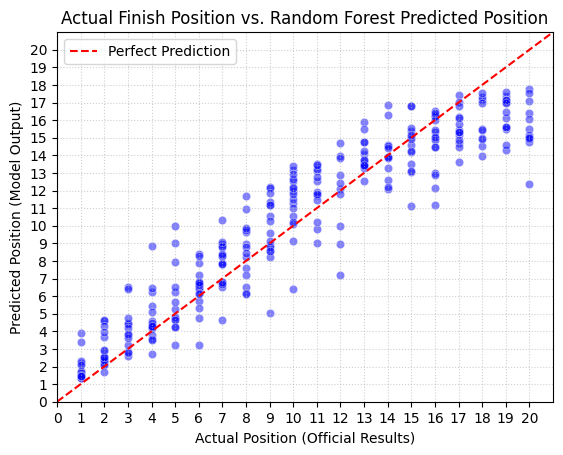

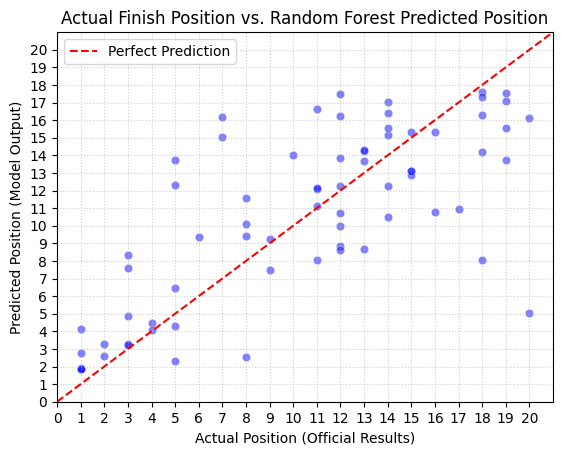

Random Forest RMSE: 3.9522


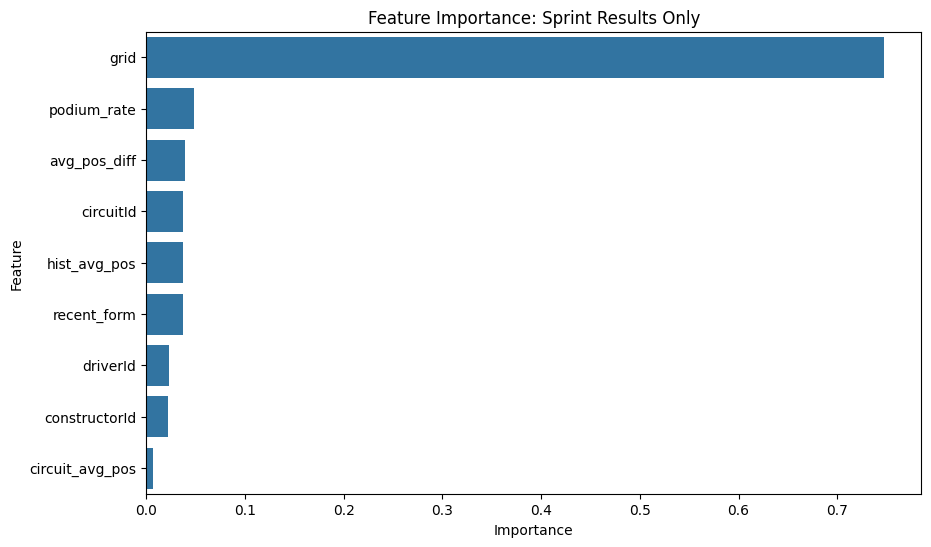

In [81]:
df = final_df.copy()

model_df = sprint_results_new.copy()


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff', 'grid', 'podium_rate']#,'circuit_mae','circuit_std']#,'recent_form', 'recent_consistency']

X = model_df[features]
y = model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=314)
model.fit(X_train, y_train)


predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)


scatterplot(y_train,model.predict(X_train))

scatterplot(y_test,predictions)


mse = mean_squared_error(y_test, predictions)

# Take the square root to get RMSE
rmse = np.sqrt(mse)
print(f"Random Forest RMSE: {rmse:.4f}")

# Feature Importance

importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()

### Collated Sprint

Training only on sprint data, but has statistics from coolated data (circuit_avg_pos, hist_av_pos, recent_form, etc.)

Model Training Complete.
Mean Absolute Error: 2.28 positions
------------------------------
Random Forest RMSE: 2.9692
0.7088020731842635
R2 Score:  0.71 


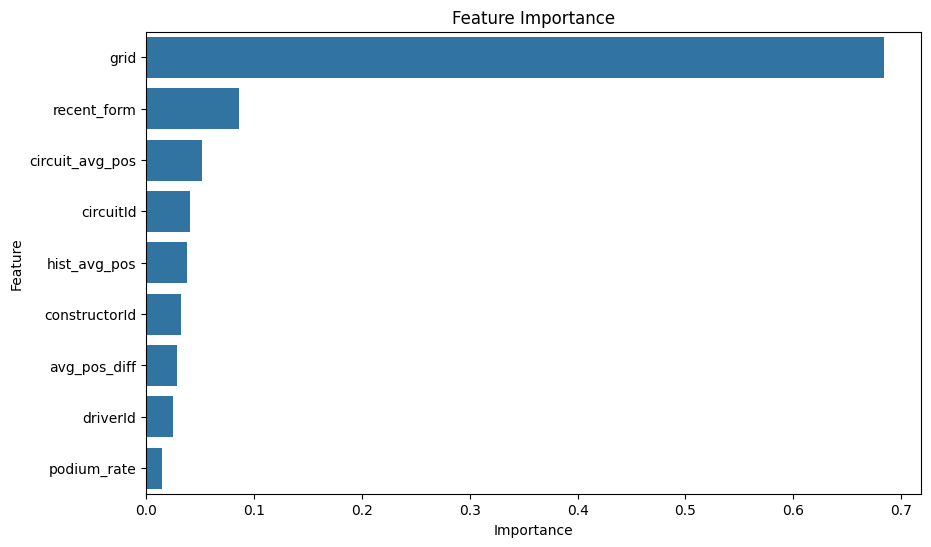

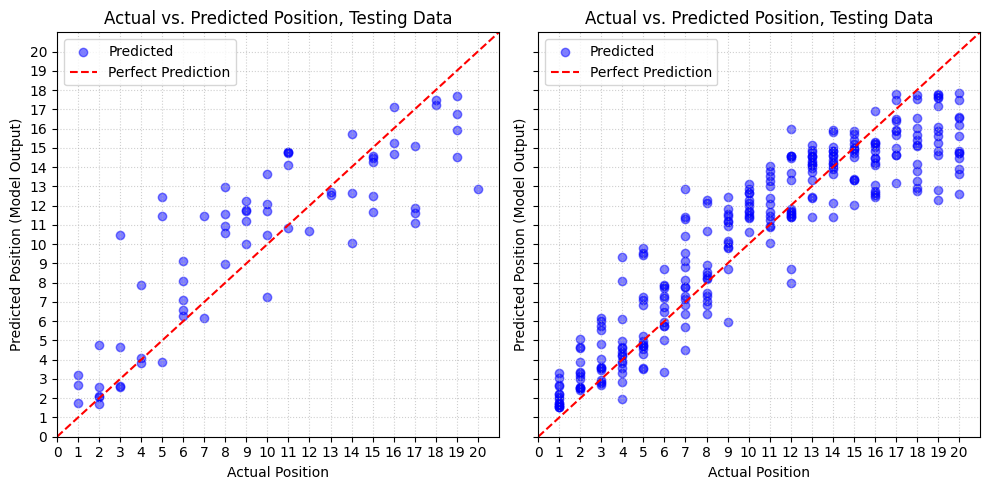

In [98]:
#df = temp_df[["resultId","raceId", "driverId", "constructorId",  'constructorName', "grid", "positionOrder",'hist_avg_pos', 'recent_form']].copy()

model_df = final_df[final_df['is_sprint']==1].copy()


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff', 'grid','podium_rate']

X = model_df[features]
y = model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=300)

model = RandomForestRegressor(max_depth=5,n_estimators=100, random_state=300)
model.fit(X_train, y_train)


predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)
#scatterplot(y_train,model.predict(X_train))

mse = mean_squared_error(y_test, predictions)

# Take the square root to get RMSE
rmse = np.sqrt(mse)
print(f"Random Forest RMSE: {rmse:.4f}")

r2 = r2_score(y_test, predictions)
print(r2)
print(f"R2 Score:  {r2:.2f} ")



importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()





fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(10,5),sharey=True)


results_comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
axes[0].scatter(x='Actual', y='Predicted', data=results_comparison, alpha=0.5, color='blue')

    
    # 2. Add the "Perfect Prediction" line (y = x)
axes[0].plot([0,21],[0,21], color='red', linestyle='--', label='Perfect Prediction')
    
    # 3. Formatting
axes[0].set_title('Actual vs. Predicted Position, Testing Data')
axes[0].set_xlabel('Actual Position')
axes[0].set_ylabel('Predicted Position (Model Output)')
axes[0].set_xticks(range(0, 21))
axes[0].set_yticks(range(0, 21))
axes[0].set_xlim(0,21)
axes[0].set_ylim(0,21)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

results_comparison2 = pd.DataFrame({
    'Actual': y_train,
    'Predicted': model.predict(X_train)
})

axes[1].scatter(x='Actual', y='Predicted', data=results_comparison2, alpha=0.5, color='blue')
   # 2. Add the "Perfect Prediction" line (y = x)
axes[1].plot([0,21],[0,21], color='red', linestyle='--', label='Perfect Prediction')
    
    # 3. Formatting
axes[1].set_title('Actual vs. Predicted Position, Testing Data')
axes[1].set_xlabel('Actual Position')
axes[1].set_ylabel('Predicted Position (Model Output)')
axes[1].set_xticks(range(0, 21))
axes[1].set_yticks(range(0, 21))
axes[1].set_xlim(0,21)
axes[1].set_ylim(0,21)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()


plt.tight_layout()
plt.show()


### Collated Sprint and Grand Prix, test on sprint only

Model Training Complete.
Mean Absolute Error: 2.87 positions
------------------------------


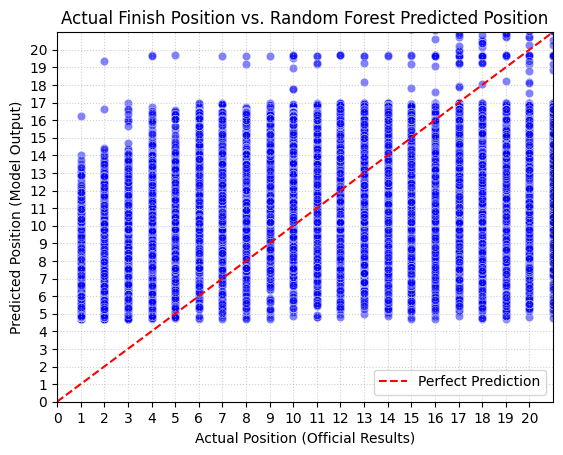

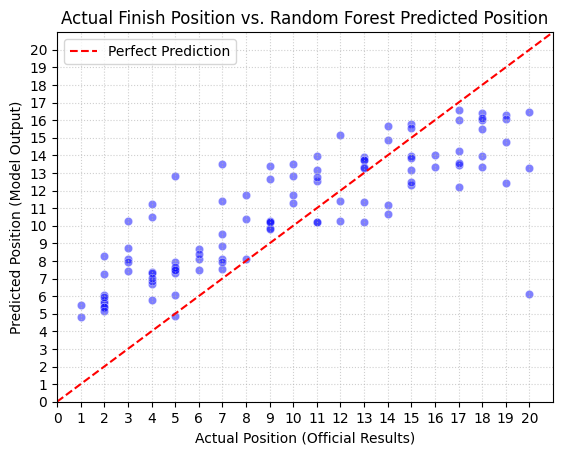

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         8
           5       0.20      0.12      0.15         8
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         7
           8       0.08      0.33      0.13         3
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         6
          12       0.00      0.00      0.00         3
          13       0.14      0.29      0.19         7
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00         7
          16       0.00      0.00      0.00         2
          17       1.00      0.17      0.29         6
          18       0.00    

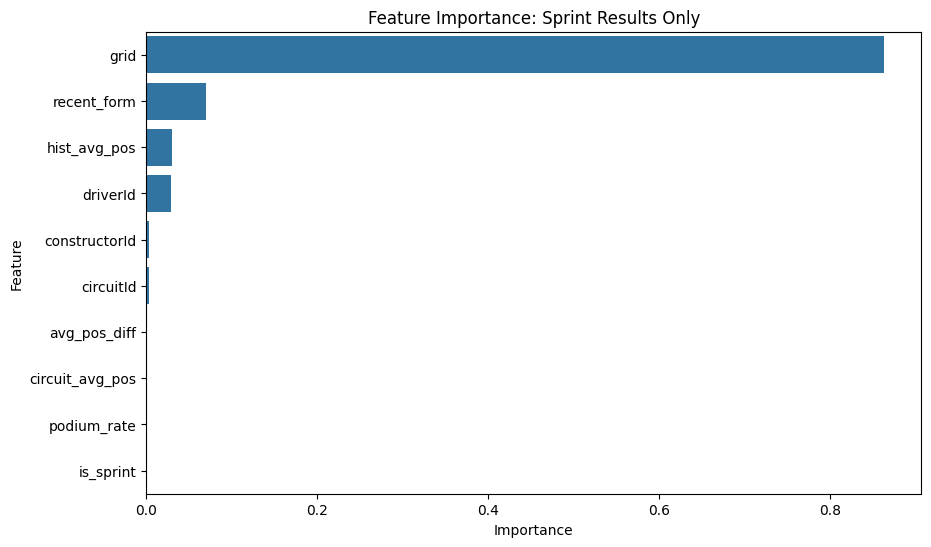

In [84]:

gp = final_df[final_df['is_sprint'] == 0]
sprint_data = final_df[final_df['is_sprint'] == 1]
sprint_train, sprint_test = train_test_split(sprint_data, test_size=0.3, random_state=314)
train_set  = pd.concat([gp,sprint_train])


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'is_sprint', 'podium_rate']
X_train = train_set[features]
y_train = train_set['positionOrder']


X_test = sprint_test[features]
y_test = sprint_test['positionOrder']

model = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=314)
model.fit(X_train, y_train)


predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)
scatterplot(y_train,model.predict(X_train))
scatterplot(y_test,predictions)

mse = mean_squared_error(y_test, predictions)
print(classification_report(y_test, np.rint(predictions).astype(int),zero_division=0))

rmse = np.sqrt(mse)
print(f"Random Forest RMSE: {rmse:.4f}")

importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()



## Random Forest Classification - Predicts if its a podium finish or not

Podium Prediction Accuracy: 90.00%


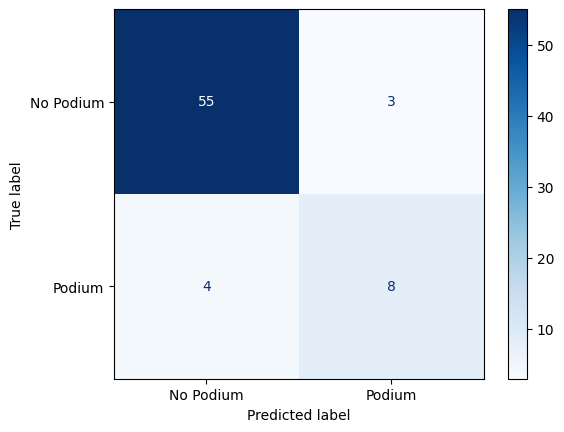

Random Forest F1-Score: 0.6957


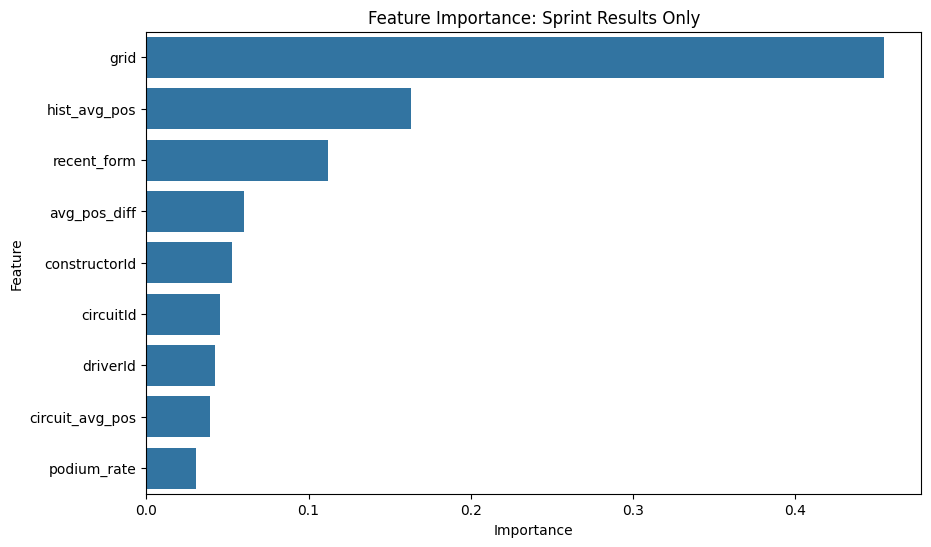

In [85]:
model_df = sprint_results_new
features = features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate']#,'circuit_mae','circuit_std','recent_consistency','hist_std_pos']

X = model_df[features]
y = model_df['is_podium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)

model = RandomForestClassifier(n_estimators=100,random_state=314)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()

f1 = f1_score(y_test, predictions, average='binary')

print(f"Random Forest F1-Score: {f1:.4f}")

importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()

Podium Prediction Accuracy: 87.14%


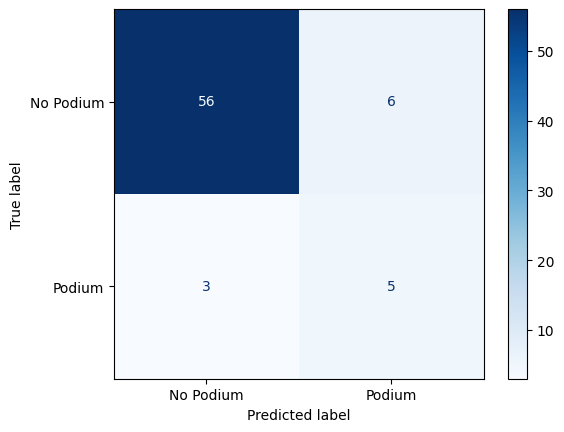

Random Forest F1-Score: 0.5263


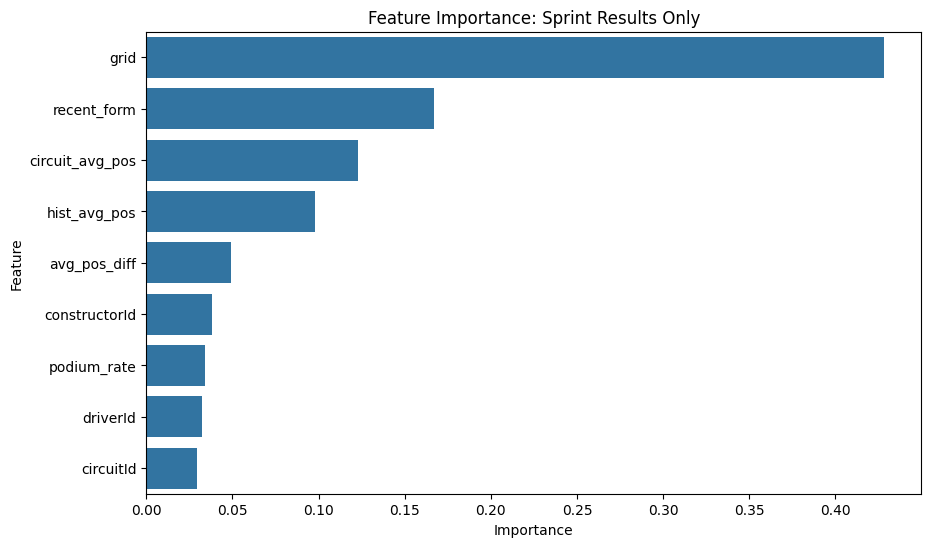

In [87]:
model_df = final_df[final_df['is_sprint']==1].copy()
features = features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate']

X = model_df[features]
y = model_df['is_podium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)

model = RandomForestClassifier(n_estimators=100,random_state=314)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()


importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
f1 = f1_score(y_test, predictions, average='binary')

print(f"Random Forest F1-Score: {f1:.4f}")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()

Podium Prediction Accuracy: 87.62%


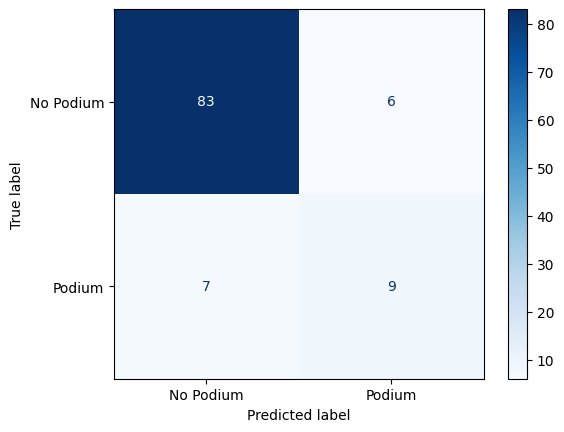

Random Forest F1-Score: 0.5806


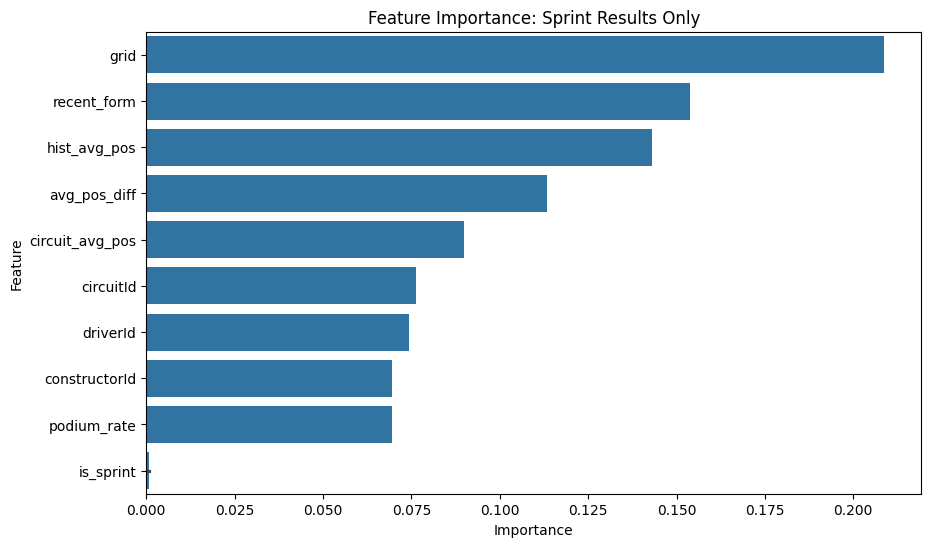

In [88]:
gp = final_df[final_df['is_sprint'] == 0]
sprint_data = final_df[final_df['is_sprint'] == 1]
sprint_train, sprint_test = train_test_split(sprint_data, test_size=0.3, random_state=314)
train_set  = pd.concat([gp,sprint_train])


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'is_sprint', 'podium_rate', 'is_sprint']
X_train = train_set[features]
y_train = train_set['is_podium']


X_test = sprint_test[features]
y_test = sprint_test['is_podium']

model = RandomForestClassifier(n_estimators=100,random_state=314)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()

f1 = f1_score(y_test, predictions, average='binary')

print(f"Random Forest F1-Score: {f1:.4f}")

importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()

## XGBoost Regression 

### Sprint Data Only

Model Training Complete.
Mean Absolute Error: 2.72 positions
------------------------------


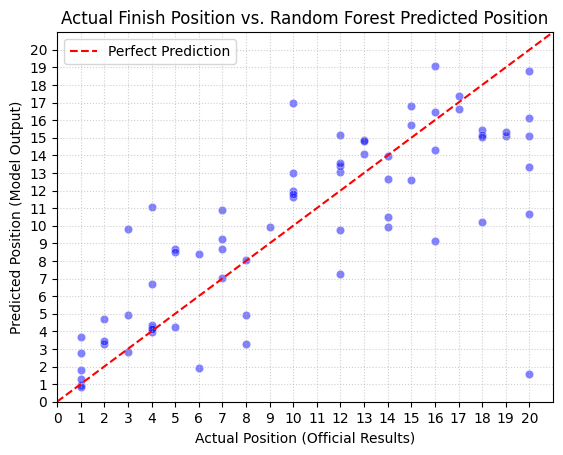

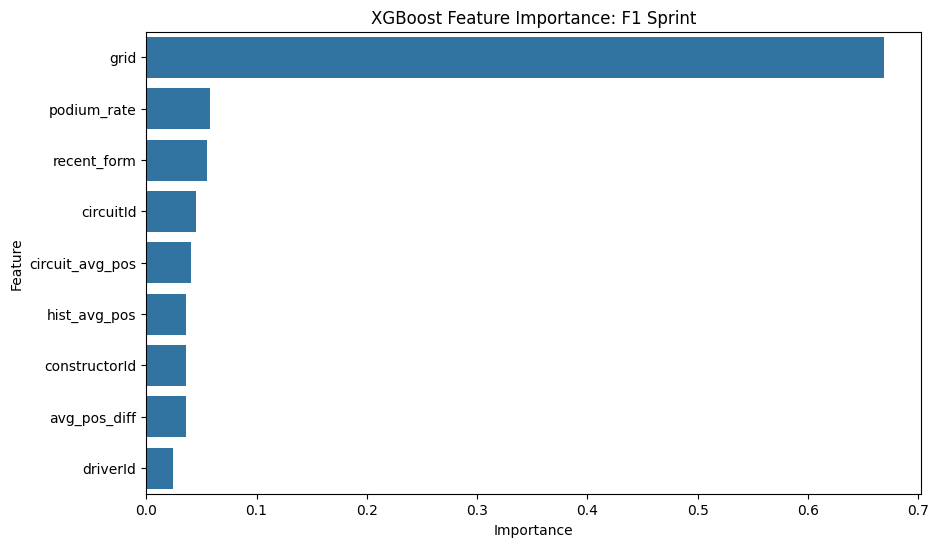

In [89]:
model_df = sprint_results_new.copy()



features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate']
X = model_df[features]
y = model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)



model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=314,
    n_jobs=-1 # Uses all CPU cores
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
actual_list = list(y_test)

mae = mean_absolute_error(y_test, predictions)
print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)

scatterplot(y_test,predictions)

importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importance: F1 Sprint')
plt.show()

### Collated Sprint Data Only

Model Training Complete.
Mean Absolute Error: 2.62 positions
------------------------------


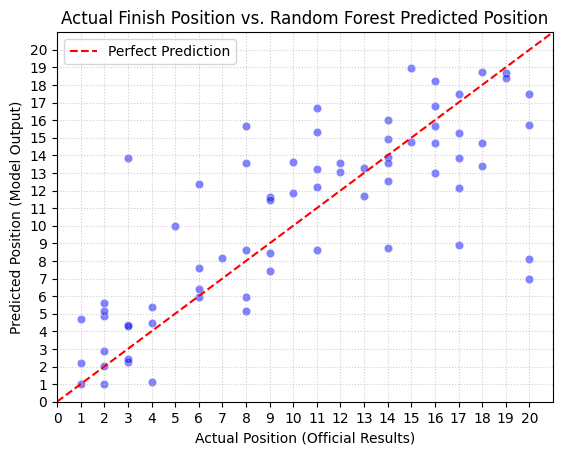

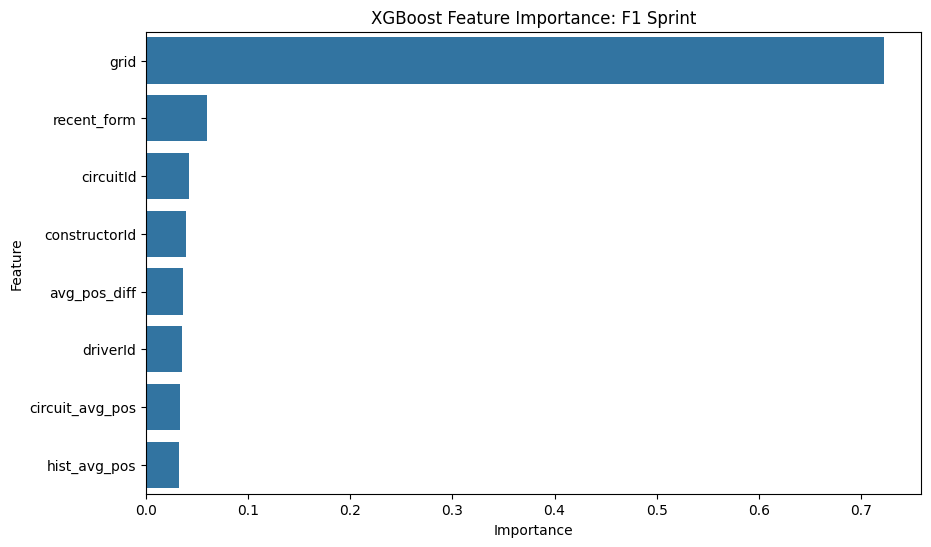

In [90]:
model_df = final_df[final_df['is_sprint']==1].copy()


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid']
X = model_df[features]
y = model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=314,
    n_jobs=-1 # Uses all CPU cores
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
actual_list = list(y_test)

mae = mean_absolute_error(y_test, predictions)
print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)

scatterplot(y_test,predictions)

importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importance: F1 Sprint')
plt.show()

### Collated Sprint and Grand Prix, test on sprint only

Model Training Complete.
Mean Absolute Error: 2.49 positions
------------------------------
Random Forest RMSE: 3.1823
R2 Score:  0.65 
0.5920484662055969


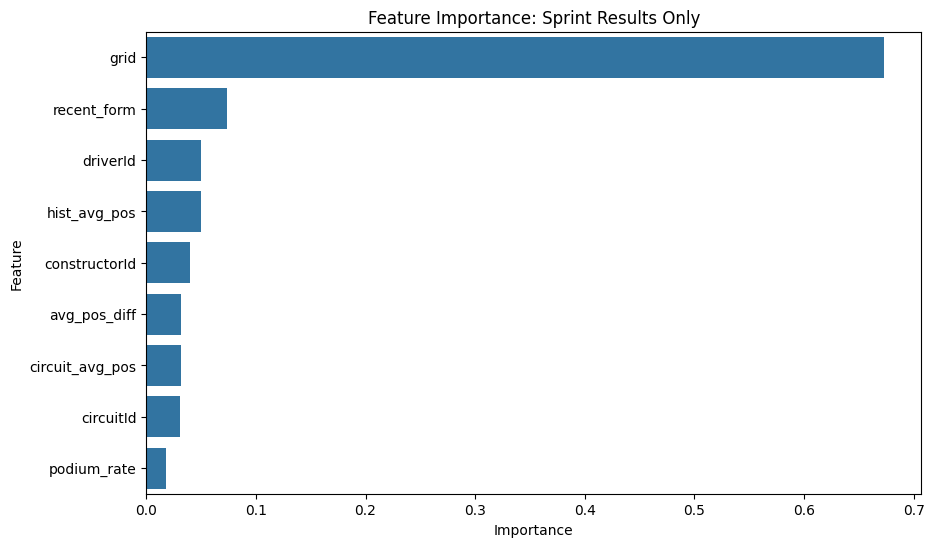

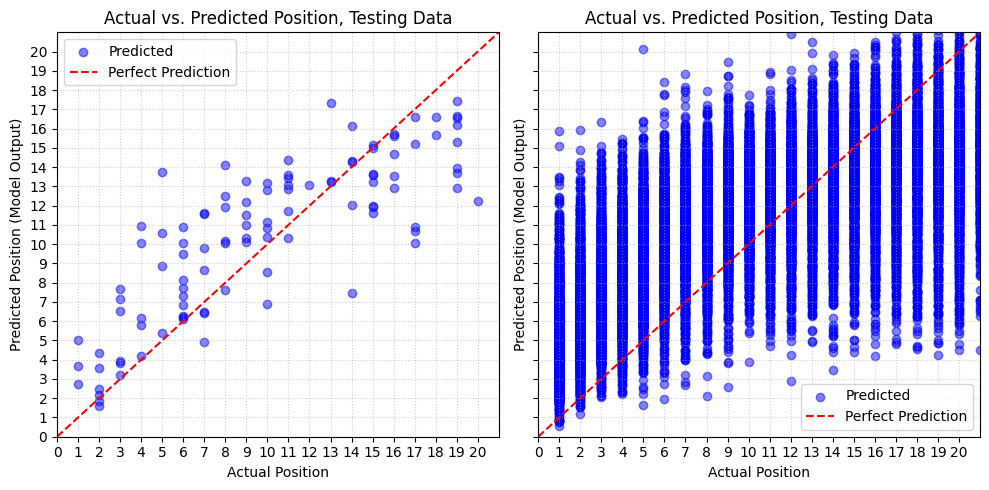

In [100]:
gp = final_df[final_df['is_sprint'] == 0]
sprint_data = final_df[final_df['is_sprint'] == 1]
sprint_train, sprint_test = train_test_split(sprint_data, test_size=0.3, random_state=300)
train_set  = pd.concat([gp,sprint_train])


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid','is_sprint']
X_train = train_set[features]
y_train = train_set['positionOrder']


X_test = sprint_test[features]
y_test = sprint_test['positionOrder']


model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=314,
    n_jobs=-1 # Uses all CPU cores
)

model.fit(X_train, y_train)
actual_list = list(y_test)


predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print(f"Model Training Complete.")
print(f"Mean Absolute Error: {mae:.2f} positions")
print("-" * 30)

mse = mean_squared_error(y_test, predictions)

# Take the square root to get RMSE
rmse = np.sqrt(mse)
print(f"Random Forest RMSE: {rmse:.4f}")

r2 = r2_score(y_test, predictions)
print(f"R2 Score:  {r2:.2f} ")
print(r2_score(y_train,(model.predict(X_train))))



importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()


fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(10,5),sharey=True)


results_comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
axes[0].scatter(x='Actual', y='Predicted', data=results_comparison, alpha=0.5, color='blue')

    
    # 2. Add the "Perfect Prediction" line (y = x)
axes[0].plot([0,21],[0,21], color='red', linestyle='--', label='Perfect Prediction')
    
    # 3. Formatting
axes[0].set_title('Actual vs. Predicted Position, Testing Data')
axes[0].set_xlabel('Actual Position')
axes[0].set_ylabel('Predicted Position (Model Output)')
axes[0].set_xticks(range(0, 21))
axes[0].set_yticks(range(0, 21))
axes[0].set_xlim(0,21)
axes[0].set_ylim(0,21)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

results_comparison2 = pd.DataFrame({
    'Actual': y_train,
    'Predicted': model.predict(X_train)
})

axes[1].scatter(x='Actual', y='Predicted', data=results_comparison2, alpha=0.5, color='blue')
   # 2. Add the "Perfect Prediction" line (y = x)
axes[1].plot([0,21],[0,21], color='red', linestyle='--', label='Perfect Prediction')
    
    # 3. Formatting
axes[1].set_title('Actual vs. Predicted Position, Testing Data')
axes[1].set_xlabel('Actual Position')
axes[1].set_ylabel('Predicted Position (Model Output)')
axes[1].set_xticks(range(0, 21))
axes[1].set_yticks(range(0, 21))
axes[1].set_xlim(0,21)
axes[1].set_ylim(0,21)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()


plt.tight_layout()
plt.show()


## XGBoost Classification - Predicts Podium

Podium Prediction Accuracy: 94.44%


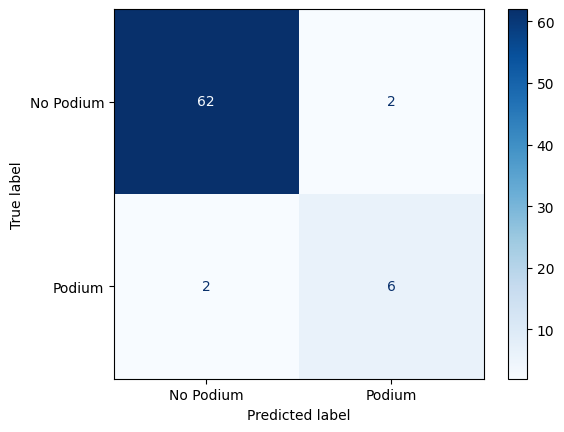

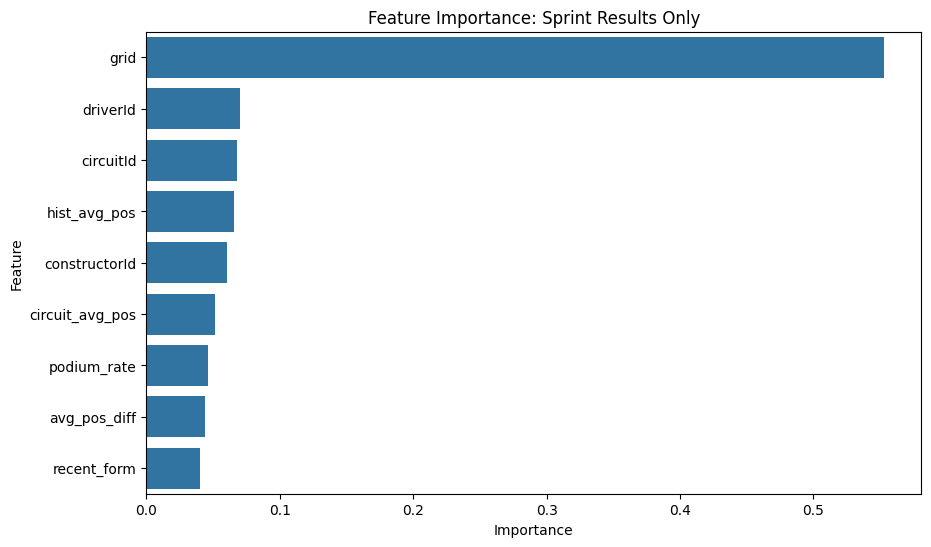

In [29]:
model_df = sprint_results_new
features = features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate']

X = model_df[features]
y = model_df['is_podium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)

model = xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=314,
    eval_metric='logloss'
)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()


importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()






Podium Prediction Accuracy: 84.72%


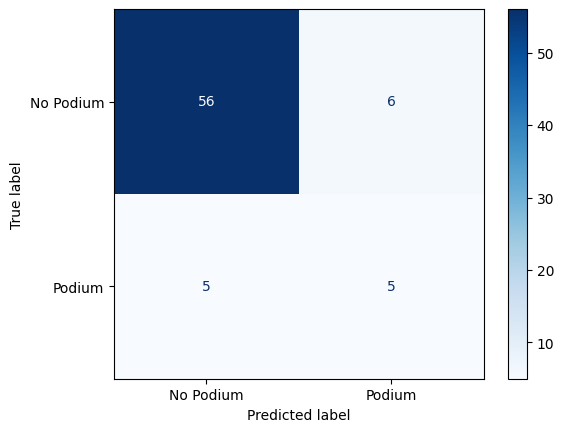

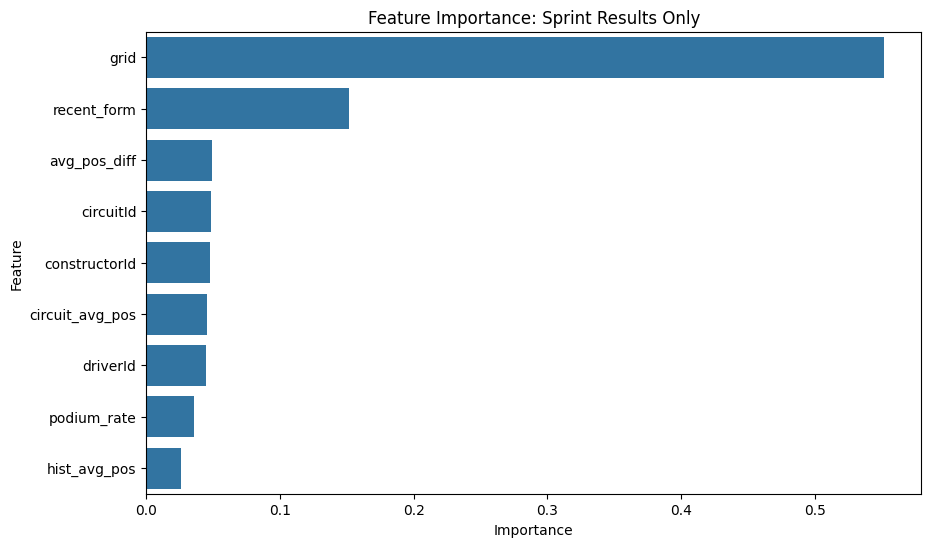

In [30]:
model_df = temp_df[temp_df['is_sprint']==1].copy()

features = features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate']

X = model_df[features]
y = model_df['is_podium']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)

model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=314,
    eval_metric='logloss'
)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()


importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()

Podium Prediction Accuracy: 93.52%


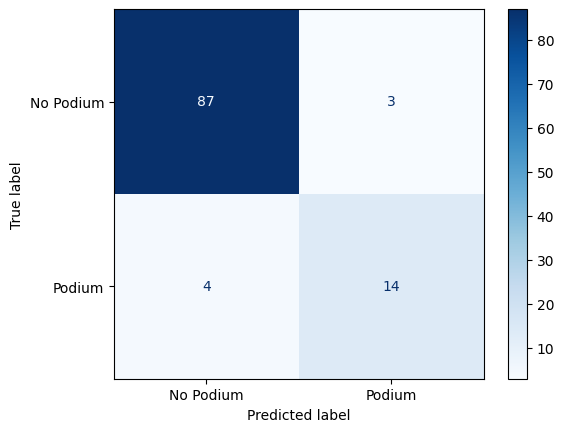

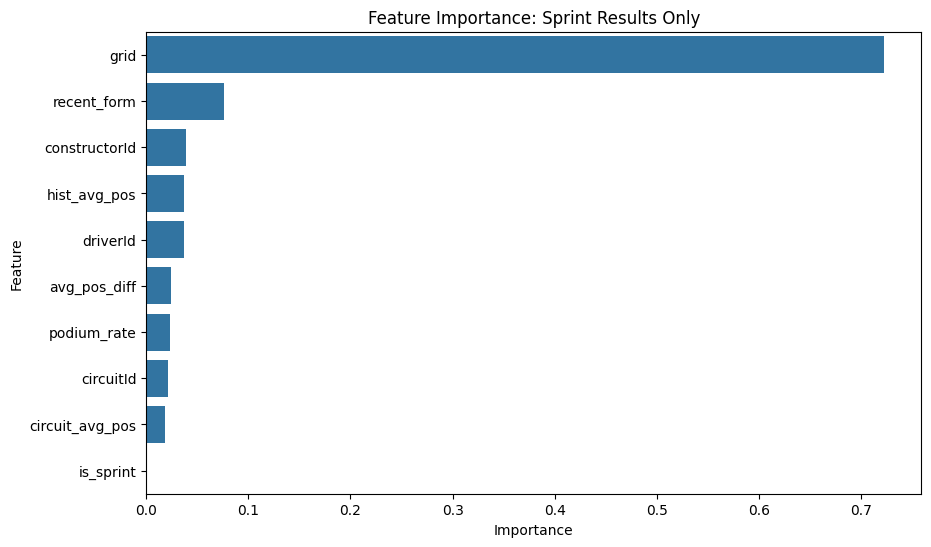

In [31]:
gp = temp_df[temp_df['is_sprint'] == 0]
sprint_data = temp_df[temp_df['is_sprint'] == 1]
sprint_train, sprint_test = train_test_split(sprint_data, test_size=0.3, random_state=314)
train_set  = pd.concat([gp,sprint_train])


features = ["driverId",'constructorId', 'circuitId',  'hist_avg_pos', 'recent_form','circuit_avg_pos', 'avg_pos_diff','grid', 'podium_rate', 'is_sprint']
X_train = train_set[features]
y_train = train_set['is_podium']


X_test = sprint_test[features]
y_test = sprint_test['is_podium']

model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=314,
    eval_metric='logloss'
)
model.fit(X_train,y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)

print(f"Podium Prediction Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Podium', 'Podium'])
disp.plot(cmap='Blues')
plt.show()


importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: Sprint Results Only')
plt.show()